# GCI World 2026 — Final Assignment
## Company A (telecom): churn analysis and business-proposal evidence base

**Pipeline.** Load and merge the two source tables, run exploratory data
analysis, engineer features, then compare five models under 5-fold
cross-validation (Logistic Regression, XGBoost, CatBoost, HistGradientBoosting
and a rank-blend ensemble), and finally review feature importance.

Every figure is written to `figures/`, styled for the University of Birmingham
dark beamer theme.

*Run top-to-bottom. Needs: pandas, scikit-learn, xgboost, catboost, seaborn.*

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
    precision_score, recall_score, f1_score,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from scipy.stats import rankdata

warnings.filterwarnings("ignore")
RNG = 42

### Plot theme and output paths
Match the University of Birmingham dark beamer palette so every figure drops
straight into the slide deck.

In [2]:
# UoB dark-theme palette (matches beamercolorthemeuob.sty)
BG      = "#1B1B1B"
FG      = "#FAFAFA"
GOLD    = "#C59A00"
LGOLD   = "#DAC064"
RED     = "#E30513"
LRED    = "#EA4F58"
BLUE    = "#2581C4"
LBLUE   = "#65A6D5"
GREY    = "#3C3C3B"

mpl.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG, "axes.edgecolor": FG,
    "xtick.color": FG, "ytick.color": FG, "axes.titlecolor": FG,
    "font.size": 13, "axes.titlesize": 15, "axes.grid": True,
    "grid.color": GREY, "grid.alpha": 0.4, "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False,
})

try:
    HERE = Path(__file__).resolve().parent
except NameError:        # running inside a notebook (no __file__)
    HERE = Path.cwd()
FIG = HERE / "figures"
FIG.mkdir(exist_ok=True)


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"  saved figures/{name}")

## 1. Load and merge the two tables
`Client.csv` (account level) and `Record.csv` (monthly usage + `churn`),
joined 1:1 on `Customer_ID`. We drop `Customer_ID` — it has no predictive value.

In [3]:
print("[1] Loading data ...")
client = pd.read_csv(HERE / "telecom" / "Client.csv")
record = pd.read_csv(HERE / "telecom" / "Record.csv")
df = record.merge(client, on="Customer_ID", how="inner").drop(columns=["Customer_ID"])
print(f"    Client {client.shape} | Record {record.shape} | merged {df.shape}")

[1] Loading data ...
    Client (100000, 50) | Record (100000, 51) | merged (100000, 99)


## 2. Exploratory data analysis
Target balance, missingness, how churn moves with key drivers, and how
correlated the numeric drivers are with each other and with churn.

[2] EDA ...


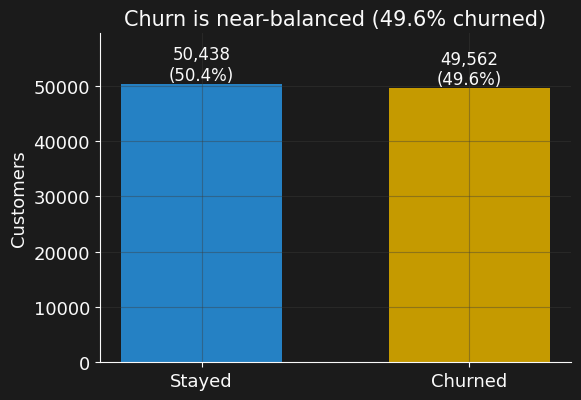

  saved figures/churn_balance.png


In [4]:
print("[2] EDA ...")

# 2a. churn balance
counts = df["churn"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(["Stayed", "Churned"], counts.values, color=[BLUE, GOLD], width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(df):.1%})",
            ha="center", va="bottom", color=FG, fontsize=12)
ax.set_ylabel("Customers")
ax.set_title("Churn is near-balanced (49.6% churned)")
ax.set_ylim(0, counts.max() * 1.18)
save(fig, "churn_balance.png")

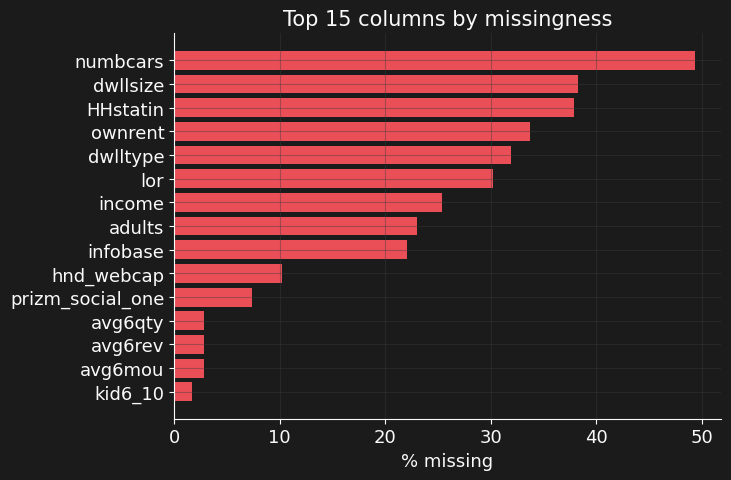

  saved figures/missingness.png


In [5]:
# 2b. top missing
miss = (df.isna().mean() * 100).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(miss.index[::-1], miss.values[::-1], color=LRED)
ax.set_xlabel("% missing")
ax.set_title("Top 15 columns by missingness")
save(fig, "missingness.png")

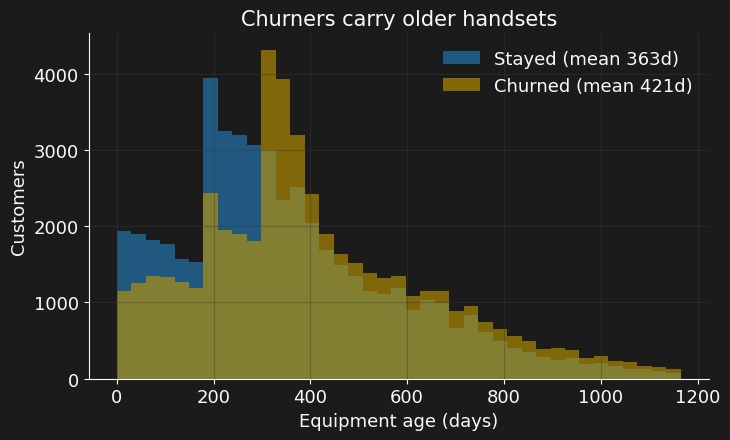

  saved figures/eqpdays_churn.png


In [6]:
# 2c. equipment age vs churn
fig, ax = plt.subplots(figsize=(7.5, 4.6))
stayed = df.loc[df.churn == 0, "eqpdays"].dropna()
churned = df.loc[df.churn == 1, "eqpdays"].dropna()
bins = np.linspace(0, df.eqpdays.quantile(0.99), 40)
ax.hist(stayed, bins=bins, alpha=0.6, label=f"Stayed (mean {stayed.mean():.0f}d)", color=BLUE)
ax.hist(churned, bins=bins, alpha=0.6, label=f"Churned (mean {churned.mean():.0f}d)", color=GOLD)
ax.set_xlabel("Equipment age (days)")
ax.set_ylabel("Customers")
ax.set_title("Churners carry older handsets")
ax.legend()
save(fig, "eqpdays_churn.png")

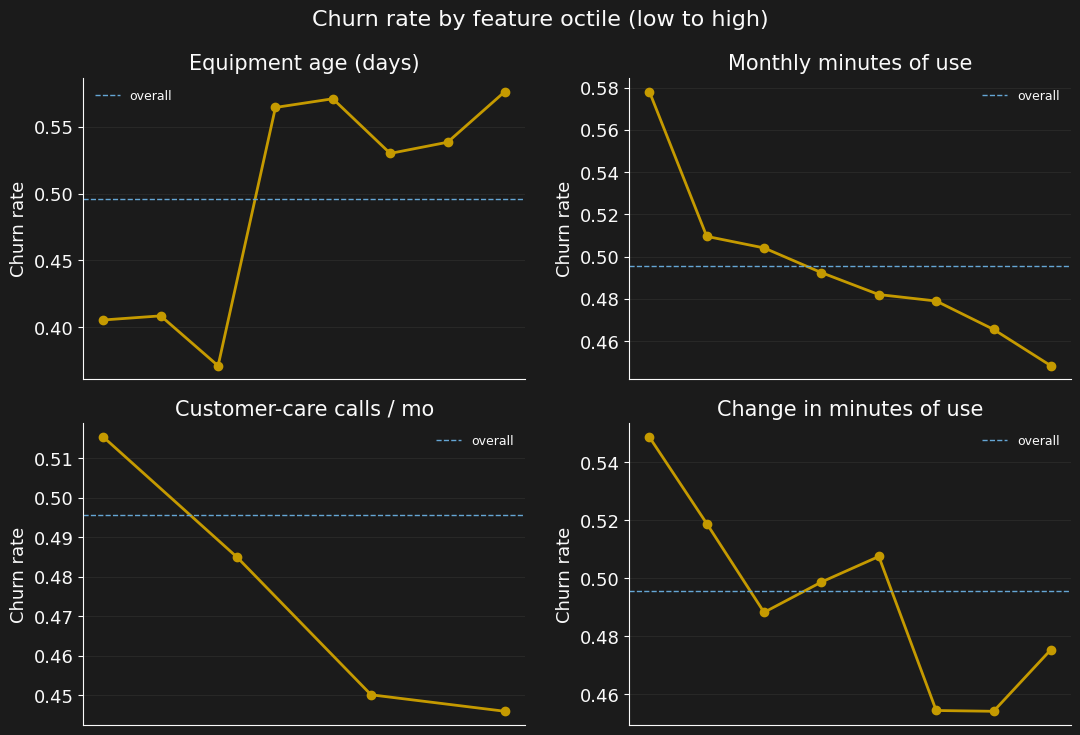

  saved figures/churn_rate_by_feature.png


In [7]:
# 2d. churn rate across business-relevant features (binned)
feat_titles = {
    "eqpdays": "Equipment age (days)",
    "mou_Mean": "Monthly minutes of use",
    "custcare_Mean": "Customer-care calls / mo",
    "change_mou": "Change in minutes of use",
}
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, (col, title) in zip(axes.ravel(), feat_titles.items()):
    s = df[[col, "churn"]].dropna()
    try:
        s["bin"] = pd.qcut(s[col], 8, duplicates="drop")
    except ValueError:
        s["bin"] = pd.cut(s[col], 8)
    rate = s.groupby("bin", observed=True)["churn"].mean()
    ax.plot(range(len(rate)), rate.values, marker="o", color=GOLD, lw=2)
    ax.axhline(df.churn.mean(), color=LBLUE, ls="--", lw=1, label="overall")
    ax.set_title(title)
    ax.set_ylabel("Churn rate")
    ax.set_xticks([])
    ax.legend(fontsize=9)
fig.suptitle("Churn rate by feature octile (low to high)", color=FG, fontsize=16)
save(fig, "churn_rate_by_feature.png")

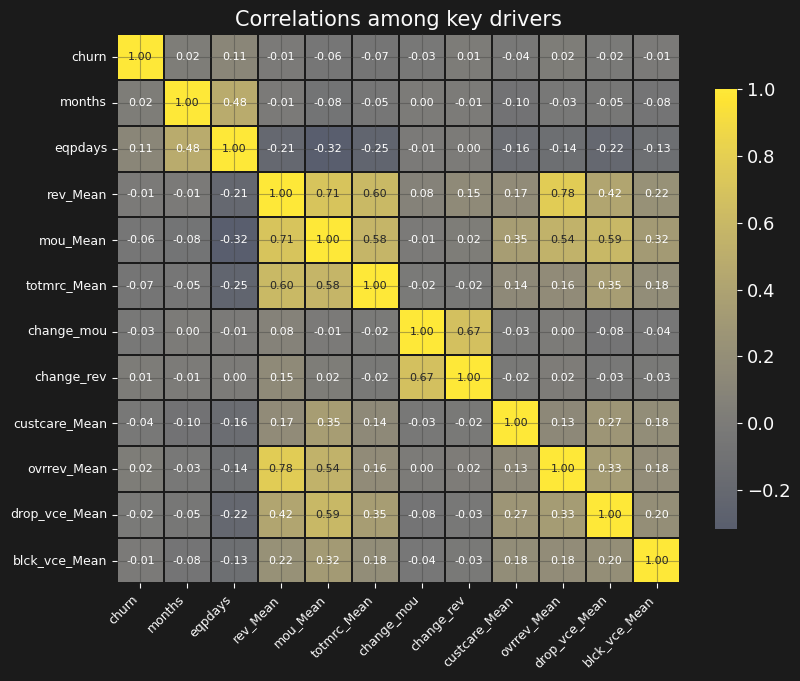

  saved figures/correlation_heatmap.png


In [8]:
# 2e. correlation heatmap of business-relevant numerics
corr_cols = ["churn", "months", "eqpdays", "rev_Mean", "mou_Mean", "totmrc_Mean",
             "change_mou", "change_rev", "custcare_Mean", "ovrrev_Mean",
             "drop_vce_Mean", "blck_vce_Mean"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="cividis", center=0,
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.8}, ax=ax,
            linewidths=0.3, linecolor=BG)
ax.set_title("Correlations among key drivers")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.setp(ax.get_yticklabels(), fontsize=9)
save(fig, "correlation_heatmap.png")

## 3. Feature engineering
Eleven business-interpretable ratio / share / momentum features. We build three
design matrices: label-encoded (LR / XGBoost / HistGB), raw-string categoricals
for CatBoost's native handling, and a no-feature baseline to measure the lift.

In [9]:
print("[3] Feature engineering ...")
eps = 1e-6

def engineer(d):
    """Add interpretable ratio, share and momentum features the business can act on."""
    d = d.copy()
    d["eqp_per_tenure"] = d["eqpdays"] / (d["months"] * 30 + eps)         # handset age vs tenure
    d["rev_per_min"]    = d["rev_Mean"] / (d["mou_Mean"] + eps)           # effective price / minute
    d["care_per_min"]   = d["custcare_Mean"] / (d["mou_Mean"] + eps)      # support intensity
    d["overage_share"]  = d["ovrrev_Mean"] / (d["rev_Mean"] + eps)        # bill-shock exposure
    d["quality_fail"]   = d[["drop_vce_Mean", "blck_vce_Mean", "unan_vce_Mean"]].sum(axis=1)
    d["usage_momentum"] = d["change_mou"] / (d["mou_Mean"].abs() + eps)   # minutes trend
    d["rev_momentum"]   = d["change_rev"] / (d["rev_Mean"].abs() + eps)   # revenue trend
    d["mou_per_sub"]    = d["mou_Mean"] / (d["uniqsubs"] + eps)           # usage per line
    d["drops_per_call"] = d["drop_blk_Mean"] / (d["attempt_Mean"] + eps)  # call-failure rate
    d["compl_rate"]     = d["complete_Mean"] / (d["attempt_Mean"] + eps)  # call-completion rate
    d["miss_count"]     = d.isna().sum(axis=1)                            # data-completeness signal
    return d

ENG = ["eqp_per_tenure", "rev_per_min", "care_per_min", "overage_share", "quality_fail",
       "usage_momentum", "rev_momentum", "mou_per_sub", "drops_per_call", "compl_rate",
       "miss_count"]

y = df["churn"].values
base = df.drop(columns="churn")
obj_cols = base.select_dtypes(include="object").columns.tolist()

# (i) engineered + label-encoded  -> Logistic Regression, XGBoost, HistGB
Xenc = engineer(base)
for c in obj_cols:
    Xenc[c] = LabelEncoder().fit_transform(Xenc[c].astype(str))

# (ii) engineered + raw string categoricals -> CatBoost native handling
Xcat = engineer(base)
for c in obj_cols:
    Xcat[c] = Xcat[c].astype(str).fillna("NA")
cat_idx = [Xcat.columns.get_loc(c) for c in obj_cols]

# (iii) label-encoded WITHOUT engineered features -> honest "before" baseline
Xbase = base.copy()
for c in obj_cols:
    Xbase[c] = LabelEncoder().fit_transform(Xbase[c].astype(str))

print(f"    {Xenc.shape[1]} features ({len(ENG)} engineered, {len(obj_cols)} categoricals)")

[3] Feature engineering ...
    109 features (11 engineered, 21 categoricals)


## 4. Modelling — 5-fold cross-validation
Out-of-fold predictions over all 100,000 customers (no held-out split wasted).
The models are layered to show the marginal value of each technique used in the
course: starting from label encoding, then adding engineered features, then
native categorical handling, and finally a rank-blend ensemble.

In [22]:
print("[4] 5-fold cross-validation (trains CatBoost; ~6 min) ...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
folds = list(skf.split(df, y))
results = {}

def evaluate(name, oof):
    pred = (oof >= 0.5).astype(int)
    results[name] = {
        "acc":  accuracy_score(y, pred),
        "auc":  roc_auc_score(y, oof),
        "prec": precision_score(y, pred),
        "rec":  recall_score(y, pred),
        "f1":   f1_score(y, pred),
        "oof":  oof,
    }
    print(f"    {name:<40} OOF AUC={results[name]['auc']:.4f}  acc={results[name]['acc']:.4f}")
    return results[name]["auc"]

[4] 5-fold cross-validation (trains CatBoost; ~6 min) ...


In [23]:
# 4a. Logistic Regression — interpretable linear baseline (needs impute + scale)
oof_lr = np.zeros(len(df))
for tr, va in folds:
    lr = Pipeline([("imp", SimpleImputer(strategy="median")),
                   ("sc", StandardScaler()),
                   ("clf", LogisticRegression(max_iter=2000, C=0.1))])
    lr.fit(Xenc.iloc[tr], y[tr])
    oof_lr[va] = lr.predict_proba(Xenc.iloc[va])[:, 1]

In [24]:
# 4b. XGBoost baseline — label-encoded, NO engineered features (the "before")
oof_xgb0 = np.zeros(len(df))
for tr, va in folds:
    m = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                      eval_metric="logloss", random_state=RNG, n_jobs=-1)
    m.fit(Xbase.iloc[tr], y[tr])
    oof_xgb0[va] = m.predict_proba(Xbase.iloc[va])[:, 1]

In [25]:
# 4c. XGBoost + engineered features
oof_xgb = np.zeros(len(df))
for tr, va in folds:
    m = XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=5, subsample=0.8,
                      colsample_bytree=0.8, min_child_weight=3, reg_lambda=1.0,
                      eval_metric="auc", random_state=RNG, n_jobs=-1)
    m.fit(Xenc.iloc[tr], y[tr])
    oof_xgb[va] = m.predict_proba(Xenc.iloc[va])[:, 1]

In [14]:
# 4d. CatBoost + engineered features (native categorical handling)
oof_cat = np.zeros(len(df))
for tr, va in folds:
    m = CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6, l2_leaf_reg=3,
                           eval_metric="AUC", random_seed=RNG, verbose=0,
                           border_count=128, thread_count=-1)
    m.fit(Xcat.iloc[tr], y[tr], cat_features=cat_idx,
          eval_set=(Xcat.iloc[va], y[va]), early_stopping_rounds=40)
    oof_cat[va] = m.predict_proba(Xcat.iloc[va])[:, 1]

In [15]:
# 4e. HistGradientBoosting + engineered features
oof_hgb = np.zeros(len(df))
for tr, va in folds:
    m = HistGradientBoostingClassifier(max_iter=600, learning_rate=0.03, max_depth=6,
                                       l2_regularization=1.0, random_state=RNG)
    m.fit(Xenc.iloc[tr], y[tr])
    oof_hgb[va] = m.predict_proba(Xenc.iloc[va])[:, 1]

In [16]:
# 4f. Ensemble — rank-blend of the three gradient-boosted models (final model)
oof_ens = (rankdata(oof_cat) + rankdata(oof_xgb) + rankdata(oof_hgb)) / (3 * len(df))

print("\n    Incremental improvement (5-fold OOF):")
evaluate("Logistic Regression",             oof_lr)
evaluate("XGBoost (baseline, no features)", oof_xgb0)
evaluate("XGBoost + features",              oof_xgb)
evaluate("CatBoost + features",             oof_cat)
evaluate("HistGradientBoosting + features", oof_hgb)
evaluate("Ensemble (final)",                oof_ens)


    Incremental improvement (5-fold OOF):
    Logistic Regression                      OOF AUC=0.6327  acc=0.5959
    XGBoost (baseline, no features)          OOF AUC=0.6972  acc=0.6409
    XGBoost + features                       OOF AUC=0.7056  acc=0.6475
    CatBoost + features                      OOF AUC=0.7041  acc=0.6475
    HistGradientBoosting + features          OOF AUC=0.7026  acc=0.6453
    Ensemble (final)                         OOF AUC=0.7064  acc=0.6484


0.7064027474514728

### 4g. Result figures
Improvement ladder, ROC comparison, and the final ensemble's confusion matrix.

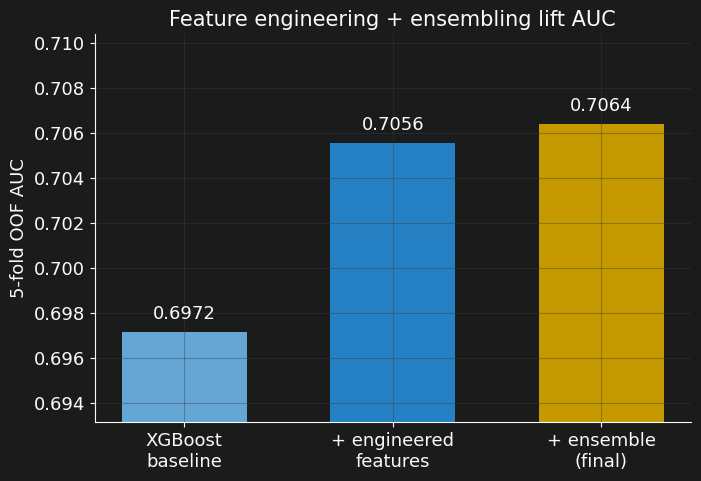

  saved figures/model_improvement.png


In [17]:
ladder = [("XGBoost\nbaseline",        results["XGBoost (baseline, no features)"]["auc"], LBLUE),
          ("+ engineered\nfeatures",   results["XGBoost + features"]["auc"],              BLUE),
          ("+ ensemble\n(final)",      results["Ensemble (final)"]["auc"],                GOLD)]
fig, ax = plt.subplots(figsize=(7.2, 5))
bars = ax.bar([s for s, _, _ in ladder], [v for _, v, _ in ladder],
              color=[c for _, _, c in ladder], width=0.6)
for b, (_, v, _) in zip(bars, ladder):
    ax.text(b.get_x() + b.get_width()/2, v + 0.0004, f"{v:.4f}",
            ha="center", va="bottom", color=FG, fontsize=13)
ax.set_ylim(ladder[0][1] - 0.004, ladder[-1][1] + 0.004)
ax.set_ylabel("5-fold OOF AUC")
ax.set_title("Feature engineering + ensembling lift AUC")
save(fig, "model_improvement.png")

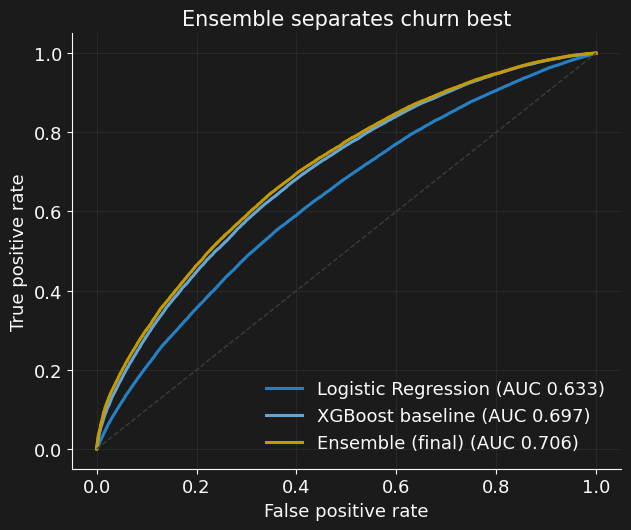

  saved figures/roc_comparison.png


In [18]:
# ROC comparison (LR vs tree baseline vs final ensemble) on OOF predictions
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, key, color in [("Logistic Regression", "Logistic Regression", BLUE),
                         ("XGBoost baseline", "XGBoost (baseline, no features)", LBLUE),
                         ("Ensemble (final)", "Ensemble (final)", GOLD)]:
    fpr, tpr, _ = roc_curve(y, results[key]["oof"])
    ax.plot(fpr, tpr, color=color, lw=2.2, label=f"{name} (AUC {results[key]['auc']:.3f})")
ax.plot([0, 1], [0, 1], color=GREY, ls="--", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Ensemble separates churn best")
ax.legend(loc="lower right")
save(fig, "roc_comparison.png")

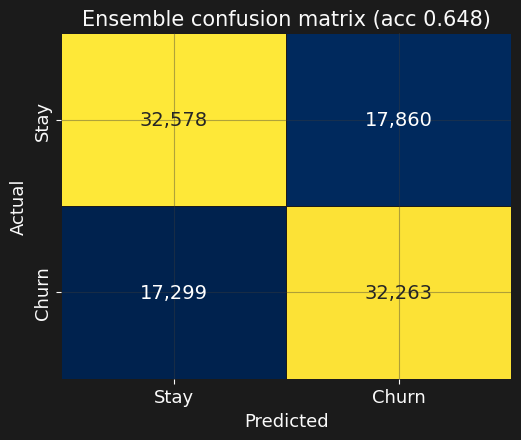

  saved figures/confusion_matrix.png


In [19]:
# confusion matrix (final ensemble, 0.5 threshold)
cm = confusion_matrix(y, (oof_ens >= 0.5).astype(int))
fig, ax = plt.subplots(figsize=(5.4, 4.6))
sns.heatmap(cm, annot=True, fmt=",d", cmap="cividis", cbar=False,
            xticklabels=["Stay", "Churn"], yticklabels=["Stay", "Churn"],
            annot_kws={"size": 14}, ax=ax, linewidths=0.5, linecolor=BG)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Ensemble confusion matrix (acc {results['Ensemble (final)']['acc']:.3f})")
save(fig, "confusion_matrix.png")

## 5. Feature importance
XGBoost (engineered features) refit on all data. Gold bars are engineered
features — several reach the top tier, confirming the feature work added signal.

[5] Feature importance ...


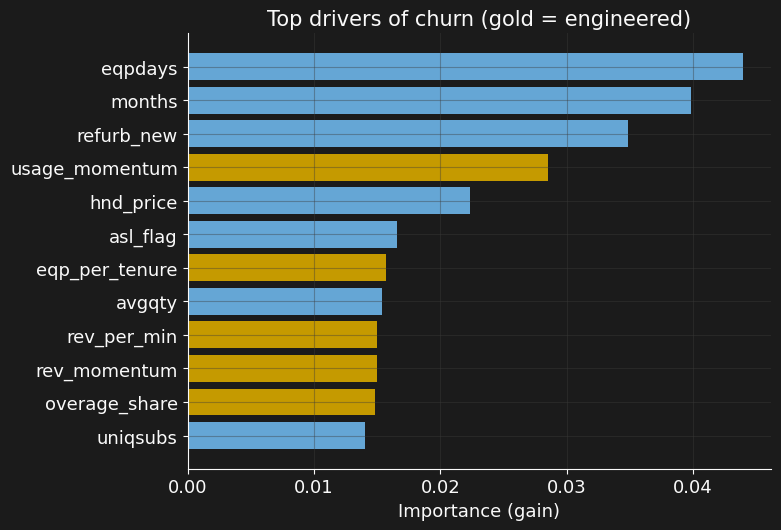

  saved figures/feature_importance.png


In [20]:
print("[5] Feature importance ...")
xgb_full = XGBClassifier(n_estimators=600, learning_rate=0.03, max_depth=5, subsample=0.8,
                         colsample_bytree=0.8, min_child_weight=3, reg_lambda=1.0,
                         eval_metric="auc", random_state=RNG, n_jobs=-1)
xgb_full.fit(Xenc, y)
imp = pd.Series(xgb_full.feature_importances_, index=Xenc.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [GOLD if f in set(ENG) else LBLUE for f in imp.index[::-1]]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors)
ax.set_xlabel("Importance (gain)")
ax.set_title("Top drivers of churn (gold = engineered)")
save(fig, "feature_importance.png")

## 6. Persist metrics for the slide deck
Writes `figures/metrics.txt` — the model-comparison table and top drivers the
deck's results slide quotes verbatim.

In [21]:
order = ["Logistic Regression", "XGBoost (baseline, no features)", "XGBoost + features",
         "CatBoost + features", "HistGradientBoosting + features", "Ensemble (final)"]
metrics_txt = FIG / "metrics.txt"
with open(metrics_txt, "w") as f:
    f.write("Model comparison - honest 5-fold out-of-fold predictions (all 100,000 customers)\n")
    f.write(f"{'model':<34}{'acc':>8}{'AUC':>8}{'prec':>8}{'rec':>8}{'F1':>8}\n")
    for name in order:
        r = results[name]
        f.write(f"{name:<34}{r['acc']:>8.4f}{r['auc']:>8.4f}{r['prec']:>8.4f}{r['rec']:>8.4f}{r['f1']:>8.4f}\n")
    base_auc = results["XGBoost (baseline, no features)"]["auc"]
    fin_auc = results["Ensemble (final)"]["auc"]
    f.write(f"\nImprovement: baseline {base_auc:.4f} -> ensemble {fin_auc:.4f} "
            f"({fin_auc - base_auc:+.4f} AUC)\n")
    f.write("\nTop 8 churn drivers (XGBoost gain; * = engineered):\n")
    for k, v in imp.head(8).items():
        star = " *" if k in set(ENG) else ""
        f.write(f"  {k:<18}{v:.4f}{star}\n")
print("    wrote figures/metrics.txt")
print("\nDONE. Figures in figures/.")

    wrote figures/metrics.txt

DONE. Figures in figures/.
